In [1]:
# import requried libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load the datasets
df = pd.read_csv("telco.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)


In [10]:
df = pd.get_dummies(df, drop_first=True)


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
ada_pred = ada.predict(X_test)
gb_pred = gb.predict(X_test)
xgb_pred = xgb.predict(X_test)


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model_name, y_test, y_pred, y_prob):
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

evaluate("AdaBoost", y_test, ada_pred, ada.predict_proba(X_test)[:,1])
evaluate("Gradient Boosting", y_test, gb_pred, gb.predict_proba(X_test)[:,1])
evaluate("XGBoost", y_test, xgb_pred, xgb.predict_proba(X_test)[:,1])



AdaBoost
Accuracy: 0.7945984363894811
Precision: 0.6615969581749049
Recall: 0.46524064171123
F1-score: 0.5463108320251178
ROC-AUC: 0.833429966195754

Gradient Boosting
Accuracy: 0.7945984363894811
Precision: 0.6615969581749049
Recall: 0.46524064171123
F1-score: 0.5463108320251178
ROC-AUC: 0.834150830093544

XGBoost
Accuracy: 0.798862828713575
Precision: 0.6511627906976745
Recall: 0.5240641711229946
F1-score: 0.5807407407407408
ROC-AUC: 0.8340175285110084


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Step 1: Define base model FIRST
base_model = DecisionTreeClassifier(max_depth=1)

# Step 2: Create AdaBoost classifier
classifier = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Step 3: Train the model
classifier.fit(X_train, y_train)   # use y_train (lowercase)

# Step 4: Predict
y_pred = classifier.predict(X_test)


<Axes: >

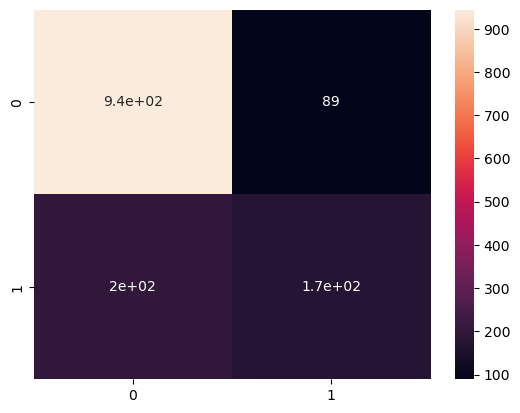

In [23]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)

In [25]:

# find accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.7945984363894811

In [26]:
# find the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)


array([[944,  89],
       [200, 174]])

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

classifier.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [41]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


In [42]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [43]:
print(y.isna().sum())  # Should be 0


7032


In [46]:
# Check NaNs in full target
print(df['Churn'].isna().sum())

# Check after splitting
print(y_train.isna().sum())


7032
5625


In [47]:
# Remove NaN rows from X and y before splitting
mask = df['Churn'].notna()
X = df.loc[mask].drop('Churn', axis=1)
y = df.loc[mask, 'Churn']
